<a href="https://colab.research.google.com/github/adarsh747/Leetcode-Problem/blob/main/Password_Strength.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import math

# mount drive for password_strength dataset
from google.colab import drive
drive.mount('/content/drive')


# The correct path to the extracted dataset is provided by kagglehub
df = pd.read_csv('/content/drive/MyDrive/11hello/data1/dataset4.csv')
df.head()

Mounted at /content/drive


,Password,Has Lowercase,Has Uppercase,Has Special Character,Length,Strength
0,<%r?.,1,0,1,5,Weak
1,l(d_l,1,0,1,5,Weak
2,"|+Z)kDTRYo:q{""(",1,1,1,15,Strong
3,gwcNB[oS5!n%OPJ,1,1,1,15,Strong
4,^vXjCCP6,1,1,1,8,Strong


In [2]:
# Map 'strength' words to numbers
strength_map = {
    'Weak': 0,
    'Medium': 1,
    'Strong': 2
}

df['Strength'] = df['Strength'].map(strength_map)


In [3]:
df.head()

,Password,Has Lowercase,Has Uppercase,Has Special Character,Length,Strength
0,<%r?.,1,0,1,5,0
1,l(d_l,1,0,1,5,0
2,"|+Z)kDTRYo:q{""(",1,1,1,15,2
3,gwcNB[oS5!n%OPJ,1,1,1,15,2
4,^vXjCCP6,1,1,1,8,2


In [4]:
df.isnull().sum()                            # check missing balues in rows
df.dropna(inplace=True)                      # remove missing rows
df['Strength'] = df['Strength'].astype(int)  # make sure target is numeric


In [5]:
# Selecting input features (lowercase, uppercase, special characters, and length)
# to be used for predicting the password strength (target variable 'Strength')

X = df[['Has Lowercase', 'Has Uppercase', 'Has Special Character', 'Length']]
y = df['Strength']                                                            # Target variable indicating the strength of the password


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Splitting the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing the Random Forest Classifier model
model = RandomForestClassifier()

# Training the model on the training data
model.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
from sklearn.metrics import classification_report, accuracy_score

# Using the trained model to predict password strength on the test data
y_pred = model.predict(X_test)

# Printing detailed classification metrics: precision, recall, f1-score, and support
print(classification_report(y_test, y_pred))

# Printing the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       429
           1       1.00      1.00      1.00       370
           2       1.00      1.00      1.00      1201

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy: 0.999


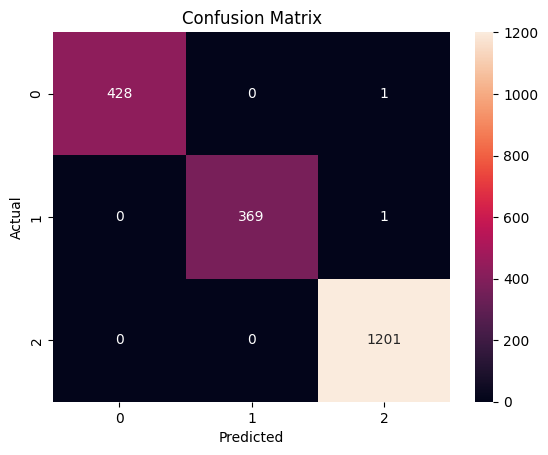

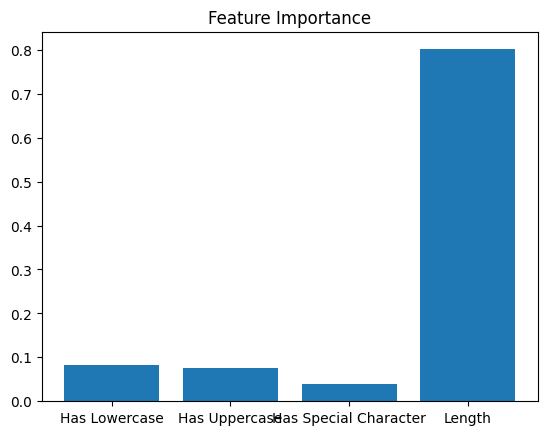

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create a confusion matrix to compare actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# Show the confusion matrix as a heatmap (with numbers inside boxes)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")       # What the model predicted
plt.ylabel("Actual")          # What the correct answer was
plt.show()

# Feature importance
importances = model.feature_importances_

# Make a bar chart to display feature importance
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()


In [9]:
import string

def extract_features(password):

    has_lower = any(c.islower() for c in password)                     # Check if password has any lowercase letters (a–z)
    has_upper = any(c.isupper() for c in password)                     # Check if password has any uppercase letters (A–Z)
    has_special = any(c in string.punctuation for c in password)       # Check if password has any special characters (!@#$ etc.)
    length = len(password)                                             # Get the length of the password
    return [int(has_lower), int(has_upper), int(has_special), length]  # Return the features as a list of integers [lowercase, uppercase, special, length]



In [10]:
password = input("Enter your password: ")        # Ask the user to input a password

features = extract_features(password)            # Extract features from the entered password
strength_num = model.predict([features])[0]      # Use the trained model to predict password strength

# Map result back to label
strength_labels = {0: "Weak", 1: "Medium", 2: "Strong"}
print(f"Predicted Strength: {strength_labels[strength_num]}")


Enter your password: adarshlmlsmvm
Predicted Strength: Medium


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [11]:
X_full = df[['Has Lowercase', 'Has Uppercase', 'Has Special Character', 'Length']]     # Select the feature columns for prediction

df['Predicted_Strength'] = model.predict(X_full)                                       # Use the trained model to predict password strength on the full dataset
reverse_map = {0: 'Weak', 1: 'Medium', 2: 'Strong'}                                    # Map numeric prediction results back to descriptive labels
df['Predicted_Strength_Label'] = df['Predicted_Strength'].map(reverse_map)

df.to_csv('password_predictions.csv', index=False)                                     # Save the updated dataframe with predictions to a CSV file
print("Predictions saved.")

Predictions saved.


In [12]:
from google.colab import files
files.download('password_predictions.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>